In [68]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from util.DataGen import nai_pulse, plastic_pulse

Text(0.5, 0, 'Frequency')

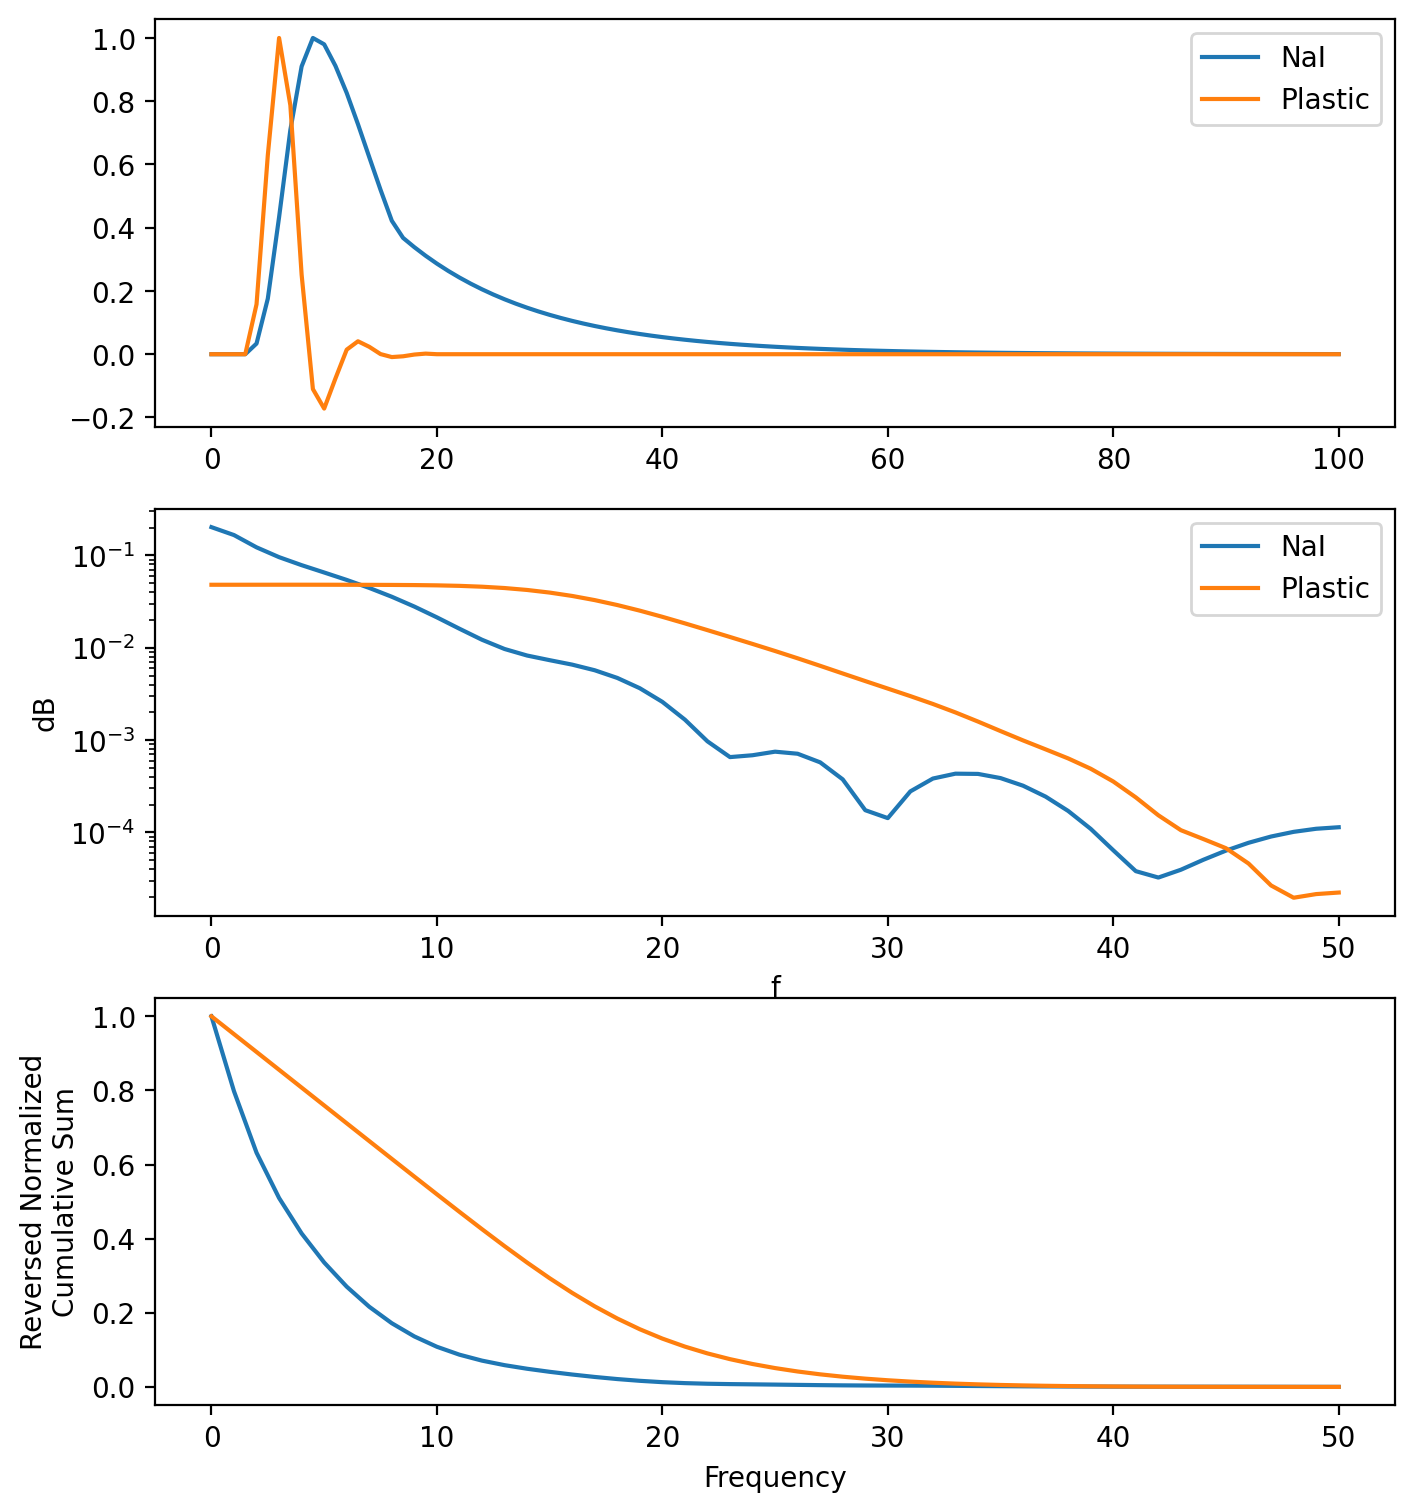

In [71]:
fig, axes = plt.subplots(3,1, figsize=(8, 9), dpi=200)

for kernel, label in zip([nai_pulse(1)[1], plastic_pulse(1)[1]],['NaI', 'Plastic']):
    
    
    size = 100
    if kernel.size < size:
        kernel = np.concatenate((kernel, np.zeros(size-kernel.size+1)))
        
    z = scipy.fft.rfft(kernel,)
    z = np.abs(z)
    z = z / np.sum(z)
    axes[0].plot(kernel, label=label)
    axes[1].plot(z, label=label)
    
    rcumsum = np.cumsum(z[::-1])[::-1]
    # rcumsum = rcumsum / np.sum(rcumsum)
    axes[2].plot(rcumsum, label=label)
    
    
axes[0].legend()

axes[1].set_yscale('log')
axes[1].set_ylabel('dB')
axes[1].set_xlabel('f')
axes[1].legend()

axes[2].set_ylabel('FD Reverse Normalized\nCumulative Sum')
axes[2].set_xlabel('Frequency')

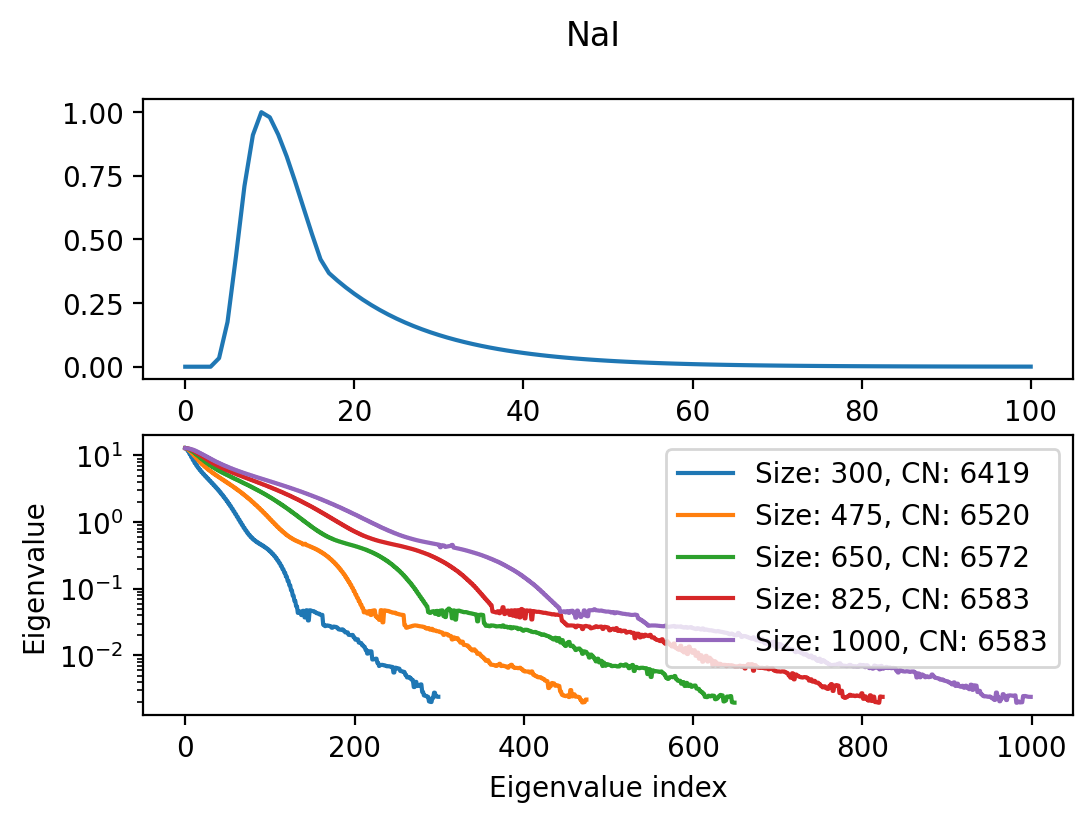

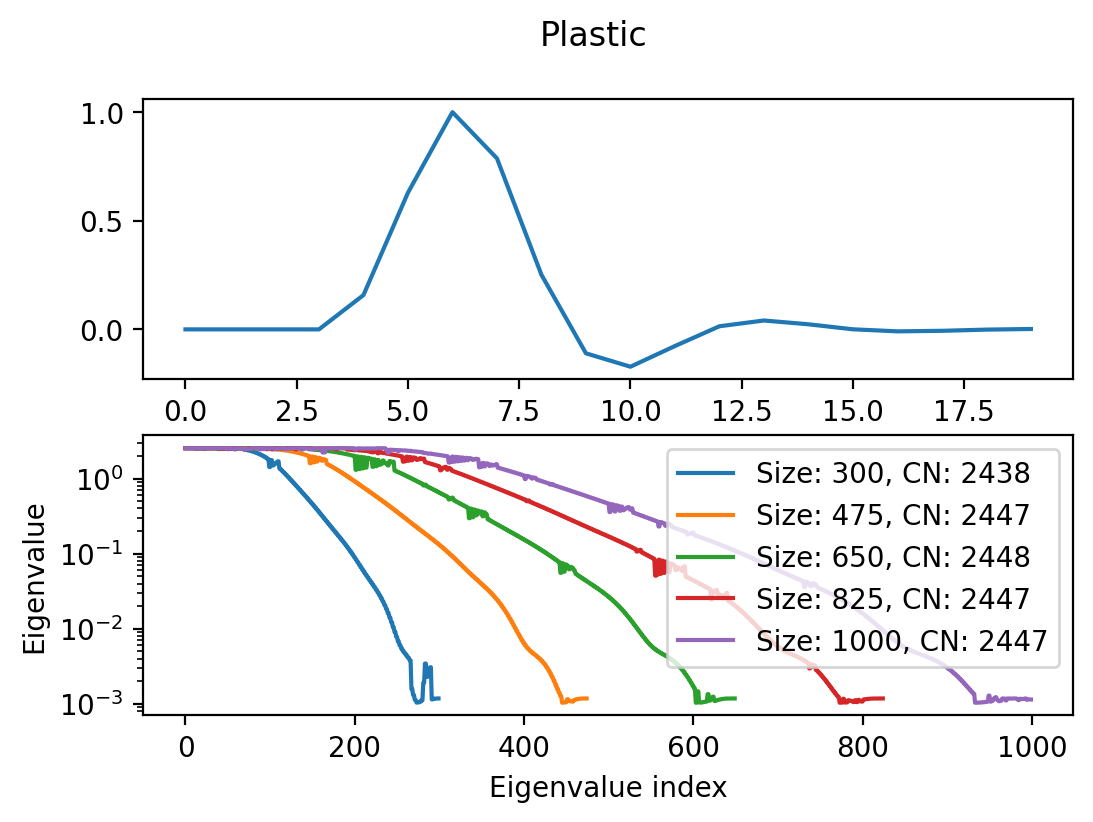

In [70]:
for function, label in zip([nai_pulse, plastic_pulse],['NaI', 'Plastic']):
    
    _, kernel = function(1)
    
    fig, axes = plt.subplots(2,1, figsize=(6, 4), dpi=200)
    fig.suptitle(label)
    
    axes[0].plot(kernel)    
    
    for size in np.linspace(300, 1000, 5).astype(int):
        
        c = np.concatenate((kernel, np.zeros(size - kernel.size)), axis=0)
        C = scipy.linalg.circulant(c)
        
        eigenvalues, eigenvectors = np.linalg.eig(C)
        
        eigenvalues = np.abs(eigenvalues)
        eigenvectors = np.abs(eigenvectors)
        
        condition_num = np.max(eigenvalues) / np.min(eigenvalues)
        
        axes[1].plot(eigenvalues, label='Size: {}, CN: {}'.format(size, int(condition_num)))
        
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Eigenvalue index')
    axes[1].set_ylabel('Eigenvalue')
    axes[1].legend()
    